In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


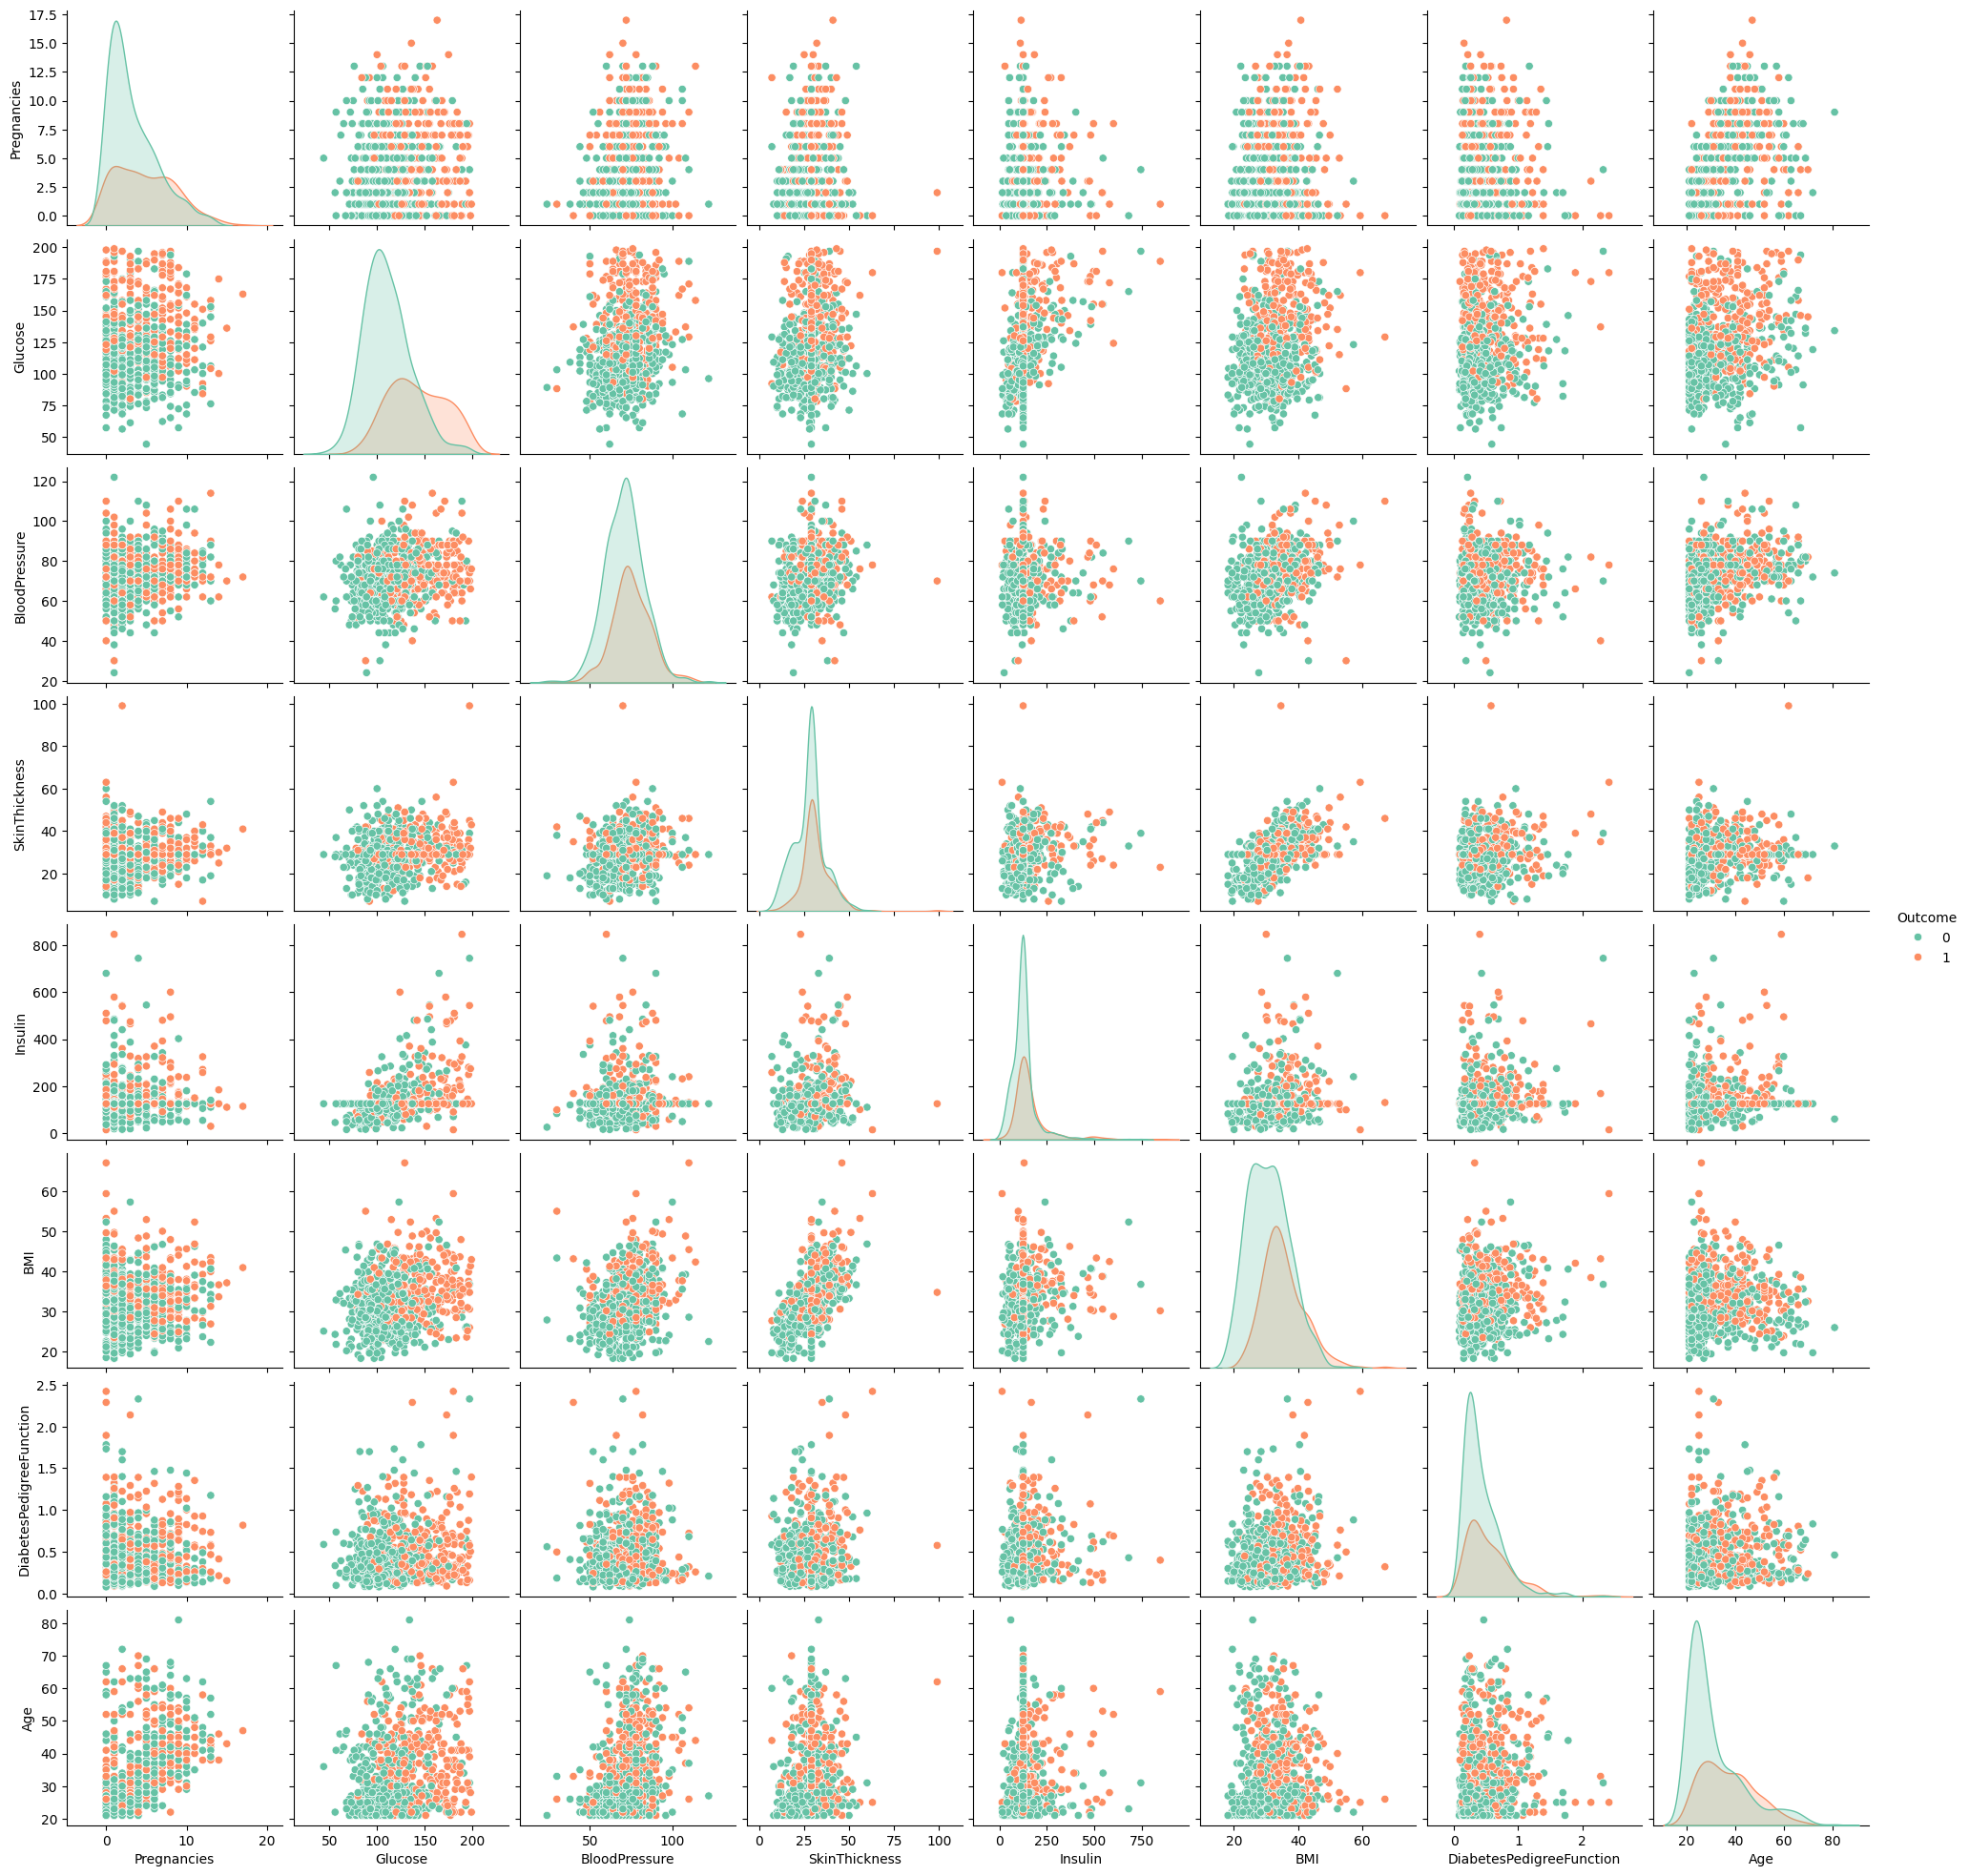

In [ ]:
sns.pairplot(df,hue='Outcome',palette='Set2')
plt.show()

In [ ]:

# Replace impossible zeros with NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Fill NaN with median
for col in zero_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


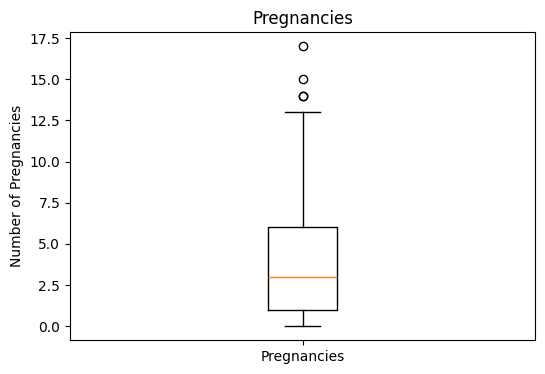

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df['Pregnancies'],tick_labels=['Pregnancies'])
plt.title('Pregnancies')
plt.ylabel('Number of Pregnancies')
plt.show()

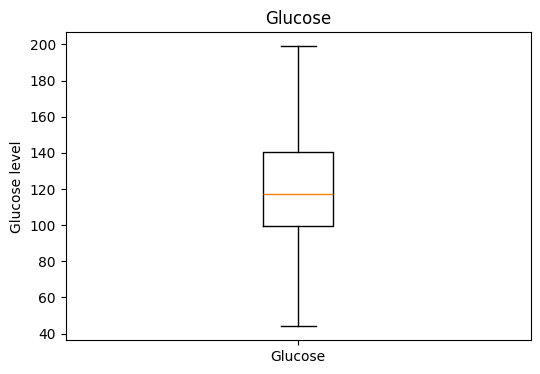

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df['Glucose'],tick_labels=['Glucose'])
plt.title('Glucose')
plt.ylabel('Glucose level')
plt.show()

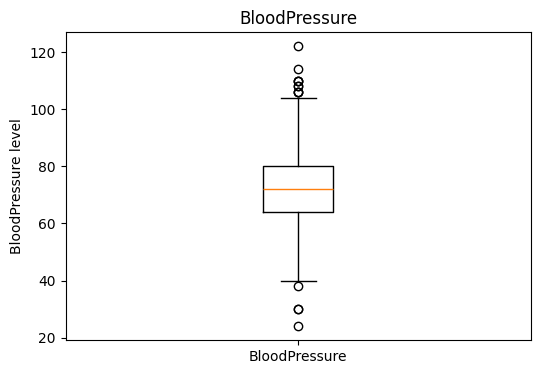

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df['BloodPressure'],tick_labels=['BloodPressure'])
plt.title('BloodPressure')
plt.ylabel('BloodPressure level')
plt.show()

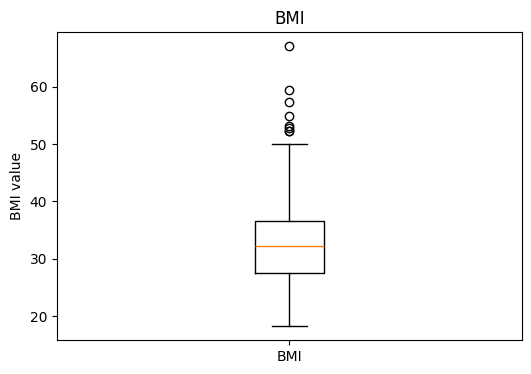

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df['BMI'],tick_labels=['BMI'])
plt.title('BMI')
plt.ylabel('BMI value')
plt.show()

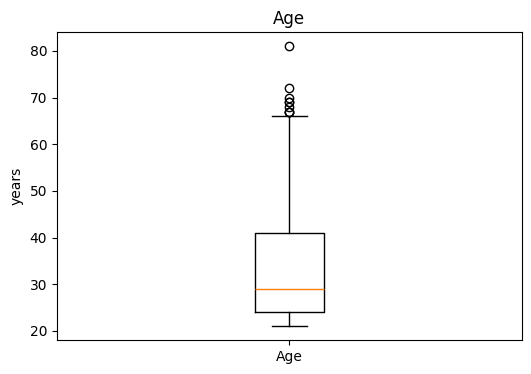

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(x=df['Age'],tick_labels=['Age'])
plt.title('Age')
plt.ylabel('years')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

x = df.drop(['Outcome'], axis=1)
y = df['Outcome']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

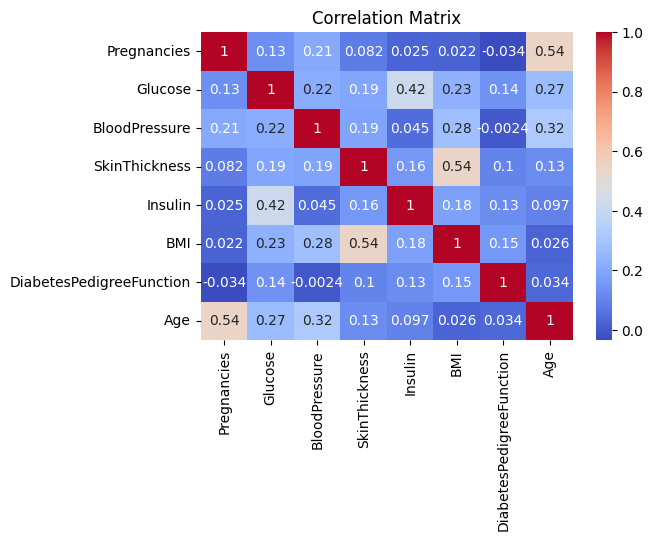

In [ ]:
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

plt.figure(figsize=(6,4))
corr_matrix = x_scaled_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
x=df.drop(['Outcome'],axis=1)
y=df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
pred=lr.predict(X_test)
accuracy=accuracy_score(y_test,pred)
print(f"Accuracy:{accuracy:.2f}")



Accuracy:0.75


In [ ]:
cr=classification_report(y_test,pred)
print(cr)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
confusion_matrix = pd.crosstab(y_test, pred, rownames=['Actual'], colnames=['Predicted'])
confusion_matrix.index = ['No Diabetes', 'Diabetes']
confusion_matrix.columns = ['No Diabetes', 'Diabetes']
confusion_matrix.index.name = 'Actual'
confusion_matrix.columns.name = 'Predicted'
print(confusion_matrix)

Predicted    No Diabetes  Diabetes
Actual                            
No Diabetes           82        17
Diabetes              21        34


In [ ]:
from sklearn.model_selection import cross_val_score
lr_cv = LogisticRegression(max_iter=200)

In [ ]:
cv_scores = cross_val_score(lr_cv, x, y, cv=5)

In [ ]:
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean accuracy: {np.mean(cv_scores)}")

Cross-validation accuracy scores: [0.75974026 0.74025974 0.78571429 0.79738562 0.77777778]
Mean accuracy: 0.7721755368814192


In [ ]:
import pickle

with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab.files import download
download('diabetes_model.pkl')
download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: scaler.pkl